In [83]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scapy.utils
from scapy.layers.dot11 import RadioTap, RadioTapTLV, Dot11
import warnings

import binascii  # for CRC-32
import functools
import struct

plt.rcParams['figure.figsize'] = (7, 3.5)
plt.rcParams['figure.max_open_warning'] = 0

In [84]:
# constellations

bpsk_const = np.array([-1, 1])
qpsk_const = np.array([-1-1j, -1+1j, 1-1j, 1+1j])/np.sqrt(2)
qam16_points = (1j * np.arange(3, -5, -2)[:, np.newaxis] + np.arange(-3, 5, 2)) / np.sqrt(10)
qam16_values = np.array(
    [[0b0010, 0b0110, 0b1110, 0b1010],
     [0b0011, 0b0111, 0b1111, 0b1011],
     [0b0001, 0b0101, 0b1101, 0b1001],
     [0b0000, 0b0100, 0b1100, 0b1000]])
qam16_const = qam16_points.ravel()[np.array([list(qam16_values.ravel()).index(n) for n in range(16)])]
qam64_points = (1j * np.arange(7, -9, -2)[:, np.newaxis] + np.arange(-7, 9, 2)) / np.sqrt(42)
qam64_values = np.array(
    [[0b000_100, 0b001_100, 0b011_100, 0b010_100, 0b110_100, 0b111_100, 0b101_100, 0b100_100],
     [0b000_101, 0b001_101, 0b011_101, 0b010_101, 0b110_101, 0b111_101, 0b101_101, 0b100_101],
     [0b000_111, 0b001_111, 0b011_111, 0b010_111, 0b110_111, 0b111_111, 0b101_111, 0b100_111],
     [0b000_110, 0b001_110, 0b011_110, 0b010_110, 0b110_110, 0b111_110, 0b101_110, 0b100_110],
     [0b000_010, 0b001_010, 0b011_010, 0b010_010, 0b110_010, 0b111_010, 0b101_010, 0b100_010],
     [0b000_011, 0b001_011, 0b011_011, 0b010_011, 0b110_011, 0b111_011, 0b101_011, 0b100_011],
     [0b000_001, 0b001_001, 0b011_001, 0b010_001, 0b110_001, 0b111_001, 0b101_001, 0b100_001],
     [0b000_000, 0b001_000, 0b011_000, 0b010_000, 0b110_000, 0b111_000, 0b101_000, 0b100_000]])
qam64_const = qam64_points.ravel()[np.array([list(qam64_values.ravel()).index(n) for n in range(64)])]
constellations = {
    'BPSK': bpsk_const,
    'QPSK': qpsk_const,
    '16-QAM': qam16_const,
    '64-QAM': qam64_const,
    'pilot': np.array([1]),
    'BPSK_rot': np.array([-1j, 1j]),
}

In [85]:
def plot_ref(ref, ax=None, refscale=1):
    const = constellations[ref] * refscale
    if ax is None:
        ax = plt
    ax.plot(const.real, const.imag, '.', color='red', markersize=3)

def constellation_plot(z, title=None, ref='bpsk', ax=None, refscale=1, lim=1.8, **kwargs):
    if ax is None:
        plt.figure(figsize=(2.5, 2.5))
        ax = plt.gca()
    ax.plot(z.real, z.imag, '.', **kwargs)
    plot_ref(ref, ax, refscale)
    ax.axis('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None:
        ax.set_title(title);

In [86]:
fs = 4e6

# OFDM parameters
Tu = round(fs / 31250)
Tcp = Tu // 4
Ts = Tu + Tcp

In [87]:
# Sequences and subcarriers

subc_seq = np.array([a for a in np.arange(40, 92, 4) if a != 64])
subc = np.array([a for a in np.arange(36, 93) if a != 64])
sig_subc = np.array([a for a in np.arange(38, 91) if a != 64])
pilot_sc = np.array([-21, -7, 7, 21]) + 64
data_subc = np.array([a for a in subc if a not in pilot_sc])
sig_data_subc = np.array([a for a in sig_subc if a not in pilot_sc])

stf_syms = np.array([
    0, 0, 1 + 1j, 0, 0, 0, -1 -1j, 0, 0, 0, 1 + 1j, 0, 0, 0, -1 -1j, 0, 0, 0, -1 -1j, 0, 0, 0, 1 + 1j, 0, 0, 0,
    0, 0, 0, 0, -1 -1j, 0, 0, 0, -1 -1j, 0, 0, 0, 1 + 1j, 0, 0, 0, 1 + 1j, 0, 0, 0, 1 + 1j, 0, 0, 0, 1 + 1j, 0, 0]) / np.sqrt(2)

ltf_left = np.array([
    1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, -1, 1, -1, 1, 1, 1, 1])
ltf_right = np.array([
    1, -1, -1, 1, 1, -1, 1, -1, 1, -1, -1, -1, -1, -1, 1, 1, -1, -1, 1, -1, 1, -1, 1, 1, 1, 1])
ltf = np.concatenate([[1, 1], ltf_left, ltf_right, [-1, -1]])

pilot_psi = np.array([1, 1, 1, -1])

# Section 17.3.5.10
pilot_polarity = np.array([
    1,1,1,1, -1,-1,-1,1, -1,-1,-1,-1, 1,1,-1,1, -1,-1,1,1, -1,1,1,-1, 1,1,1,1, 1,1,-1,1,
    1,1,-1,1, 1,-1,-1,1, 1,1,-1,1, -1,-1,-1,1, -1,1,-1,-1, 1,-1,-1,1, 1,1,1,1, -1,-1,1,1,
    -1,-1,1,-1, 1,-1,1,1, -1,-1,-1,1, 1,-1,-1,-1, -1,1,-1,-1, 1,-1,1,1, 1,1,-1,1, -1,1,-1,1,
    -1,-1,-1,-1, -1,1,-1,1, 1,-1,1,-1, 1,1,1,-1, -1,1,-1,-1, -1,1,1,1, -1,-1,-1,-1, -1,-1,-1])

# Table 23-22—Traveling pilot positions for NSTS=1, 2 MHz S1G PPDU
traveling_pilot_subc = np.array(
    [[-28, -24, -20, -16, -26, -22, -18, -27, -23, -19, -15, -25, -21, -17],
     [-12, -8, -4, -2, -14, -10, -6, -11, -7, -3, 1, -13, -9, -5],
     [4, 8, 12, 16, 2, 6, 10, 5, 9, 13, 17, -1, 3, 7],
     [20, 24, 28, 26, 14, 18, 22, 21, 25, 23, 27, 11, 15, 19]]).T + 64

def data_traveling_subc(n):
    return np.array([s for s in subc if s not in traveling_pilot_subc[n]])

In [88]:
# Viterbi algorithm
def viterbi(y, s0=0):
    nu = 6
    # States are encoded a nu-bit numbers, where the new bits are feed into the MSB
    M = np.full(2**nu, np.inf)
    M[s0] = 0
    paths = np.empty((2**nu, y.shape[0]), 'uint8')
    for t in range(y.shape[0]):
        yt = y[t, :]
        M_prev = M
        paths_prev = paths        
        M = np.full(2**nu, np.inf)
        paths = np.empty((2**nu, y.shape[0]), 'uint8')
        for r in range(2**nu):
            for bit in [0, 1]:
                s = (r >> 1) | (bit << (nu-1))
                d0 = (bit ^ r ^ (r >> 1) ^ (r >> 3) ^ (r >> 4)) & 1
                d1 = (bit ^ r ^ (r >> 3) ^ (r >> 4) ^ (r >> 5)) & 1
                d0 = 2*d0 - 1
                d1 = 2*d1 - 1
                Brs = -(d0 * yt[0] + d1 * yt[1])
                new = M_prev[r] + Brs
                if new < M[s]:
                    M[s] = new
                    paths[s, :t] = paths_prev[r, :t]
                    paths[s, t] = bit
    return np.array(paths[s0], 'uint8')

def convencoder(u):
    s = 0
    d = []
    for b in u:
        d.append((b ^ s ^ (s >> 1) ^ (s >> 3) ^ (s >> 4)) & 1)
        d.append((b ^ s ^ (s >> 3) ^ (s >> 4) ^ (s >> 5)) & 1)
        s = (s >> 1) | (b << 5)
    return d

In [89]:
def crc4(bits):
    r = 0xf
    for b in bits:
        if b ^ (r >> 3):
            r = (r << 1) ^ 0x3
        else:
            r = r << 1
        r = r & 0xf
    return r ^ 0xf

def crc8(bits):
    r = 0xff
    for b in bits:
        if b ^ (r >> 7):
            r = (r << 1) ^ 0x7
        else:
            r = r << 1
        r = r & 0xff
    return r ^ 0xff

def check_fcs(frame):
    return binascii.crc32(frame[:-4]) == struct.unpack('<I', frame[-4:])[0]

In [90]:
def maxss(a, b):
    d = np.abs(a - b)
    c = np.zeros(a.shape)
    c[d < 37] = np.exp(-d[d < 37])
    c[d < 9] = np.log1p(c[d < 9])
    return np.maximum(a, b) + c


def llr_demod(symbols, noise_sigma, constellation):
    dists = -np.abs(symbols - constellation[:, np.newaxis])**2 / (2 * noise_sigma**2)
    bits_per_symbol = round(np.log2(len(constellation)))
    llrs = np.empty((symbols.size, bits_per_symbol))
    for j in range(bits_per_symbol):
        is_one = np.where((np.arange(len(constellation)) >> (bits_per_symbol - 1 - j)) & 1)[0]
        llrs[:, j] = (
            functools.reduce(maxss, (dists[k] for k in range(len(constellation)) if (k >> (bits_per_symbol - 1 - j)) & 1 == 0))
            - functools.reduce(maxss, (dists[k] for k in range(len(constellation)) if (k >> (bits_per_symbol - 1 - j)) & 1 == 1)))
    return llrs.ravel()

In [91]:
def descrambler(data):
    reg = 0
    out = np.empty_like(data)
    for j, b in enumerate(data):        
        if j < 7:
            fb = b            
        else:
            fb = ((reg >> 3) ^ (reg >> 6)) & 1
        out[j] = b ^ fb
        reg = ((reg << 1) | fb) & 0x7f
    return out

In [92]:
wireshark_packets = []

def decode_ppdu(start_idx, *, plots=False, verbose=False):
    # STF Tu/4-lag correlation to obtain coarse CFO
    y = x[start_idx:][:2*Ts]
    stf_corr = np.sum(y[Tcp:] * np.conjugate(y[:-Tcp]))
    coarse_cfo = np.angle(stf_corr) / Tcp  # rad/s
    coarse_cfo_hz = coarse_cfo * fs / (2 * np.pi)
    if verbose:
        print(f'Coarse CFO: {coarse_cfo_hz:.3f} Hz')
    
    # STF Ts-lag correlation to obtain fine CFO
    y = x[start_idx:][:2*Ts] * np.exp(-1j*(coarse_cfo)*np.arange(2*Ts))
    stf_corr = np.sum(y[Ts:] * np.conjugate(y[:Ts]))
    fine_cfo = np.angle(stf_corr) / Ts  # rad/s
    fine_cfo_hz = fine_cfo * fs / (2 * np.pi)
    cfo = coarse_cfo + fine_cfo
    cfo_hz = coarse_cfo_hz + fine_cfo_hz
    if verbose:
        print(f'Fine CFO: {fine_cfo_hz:.3f} Hz')
        print(f'Total CFO: {cfo_hz:.3f} Hz')

    # STF demodulation to obtain STO
    # STF does not have a cyclic prefix. Demodulate Tcp / 2 into the symbol to be tolerant to STO
    cp_offset = Tcp // 2
    cp_corr = -Tcp // 2
    stf_samples = np.empty((2, Tu), 'complex')
    for j in range(2):
        stf_samples[j] = (
            x[start_idx + cp_offset + j * Ts:][:Tu]
            * np.exp(-1j * cfo * (np.arange(Tu) + cp_offset + j * Ts))
        )
    stf = (
        np.fft.fftshift(np.fft.fft(stf_samples), axes=1)
        * np.exp(1j*2*np.pi*cp_corr*np.fft.fftshift(np.fft.fftfreq(Tu)))
    )
    stf = stf[:, -26+64:27+64] * np.conj(stf_syms)
    stf = stf[:, stf_syms != 0]
    stf_avg = np.sum(stf, axis=0)
    # There are STF subcarriers every 4 subcarriers, except for the DC subcarrier, which is missing
    # (causing a jump of 8 subcarriers). Put the DC subcarrier as 0 and perform an FFT to obtain
    # coarse STO
    stf_avg_with_dc = np.zeros(stf_avg.size + 1, 'complex')
    stf_avg_with_dc[:stf_avg.size//2] = stf_avg[:stf_avg.size//2]
    stf_avg_with_dc[-stf_avg.size//2:] = stf_avg[-stf_avg.size//2:]
    stf_fft = np.abs(np.fft.fft(stf_avg_with_dc))
    stf_fft_max_idx = np.argmax(stf_fft)
    if stf_fft_max_idx >= stf_fft.size // 2:
        stf_fft_max_idx -= stf_fft.size
    coarse_sto = -stf_fft_max_idx / (4 * stf_fft.size) * Tu
    if verbose:
        print(f'Coarse STO: {coarse_sto:.2f} samples')
    stf_subc_idxs = np.arange(-26, 27)[stf_syms != 0]
    stf_without_coarse = stf_avg * np.exp(1j*2*np.pi*coarse_sto*stf_subc_idxs/Tu)
    avg_phase = np.angle(np.average(stf_without_coarse))
    fine_sto = -np.polyfit(stf_subc_idxs, np.angle(stf_without_coarse * np.exp(-1j * avg_phase)), 1)[0] / (2 * np.pi) * Tu
    sto = coarse_sto + fine_sto
    if verbose:
        print(f'Fine STO: {fine_sto:.3f} samples')
        print(f'Total STO: {sto:.3f} samples')
    stf_without_sto = stf_avg * np.exp(1j*2*np.pi*sto*stf_subc_idxs/Tu)

    # Adjust start_idx taking into account STO estimate
    start_idx += round(sto)
    sto -= round(sto)

    # LTF-1 demodulation to estimate channel
    cp_corr = Tcp // 2  # demodulate in the middle of the cyclic prefix
    ltf1_samples = np.empty((2, Tu), 'complex')
    for j in range(2):
        # LTF-1 has a double GI
        cp_offset = 2 * Tcp - Tcp // 2 if j == 0 else Tcp // 2
        ltf1_samples[j] = (
            x[start_idx + cp_offset + (j + 2) * Ts:][:Tu]
            * np.exp(-1j * cfo * (np.arange(Tu) + cp_offset + (j + 2) * Ts))
        )
    ltf1 = (
        np.fft.fftshift(np.fft.fft(ltf1_samples), axes=1)
        * np.exp(1j*2*np.pi*(cp_corr + sto)*np.fft.fftshift(np.fft.fftfreq(Tu)))
    )
    ltf1 = ltf1[:, subc] * ltf
    ltf1_avg = np.average(ltf1, axis=0)
    h_est = np.full(Tu, np.nan, 'complex')
    h_est[subc] = ltf1_avg

    # Equalize LTF-1 for constellation plotting
    ltf1_eq = ltf1 / h_est[subc]

    # Demodulate STF again with STO estimate
    cp_offset = Tcp // 2
    cp_corr = -Tcp // 2
    for j in range(2):
        stf_samples[j] = (
            x[start_idx + cp_offset + j * Ts:][:Tu]
            * np.exp(-1j * cfo * (np.arange(Tu) + cp_offset + j * Ts))
        )
    stf = (
        np.fft.fftshift(np.fft.fft(stf_samples), axes=1)
        * np.exp(1j*2*np.pi*(cp_corr + sto)*np.fft.fftshift(np.fft.fftfreq(Tu)))
    )
    stf = stf[:, -26+64:27+64] * np.conj(stf_syms) * np.sqrt(12/56)
    stf = stf[:, stf_syms != 0]
    stf_eq = stf / h_est[-26+64:27+64][stf_syms != 0]

    # Demodulate SIG / SIG-A
    cp_offset = Tcp // 2  # demodulate in the middle of the cyclic prefix
    cp_corr = Tcp // 2  
    sig_samples = np.empty((2, Tu), 'complex')
    for j in range(2):
        sig_samples[j] = (
            x[start_idx + cp_offset + (j + 4) * Ts:][:Tu]
            * np.exp(-1j * cfo * (np.arange(Tu) + cp_offset + (j + 4) * Ts))
        )
    sig = (
        np.fft.fftshift(np.fft.fft(sig_samples), axes=1)
        * np.exp(1j*2*np.pi*(cp_corr + sto)*np.fft.fftshift(np.fft.fftfreq(Tu)))
    )
    sig_pilot = sig[:, pilot_sc] / h_est[pilot_sc] * pilot_psi * np.sqrt(sig_subc.size/56)
    sig_data = sig[:, sig_data_subc] / h_est[sig_data_subc] * np.sqrt(sig_subc.size/56)

    # determine if SIG vs SIG-A (S1G_SHORT vs S1G_LONG PPDU)
    is_long = np.sum(np.abs(sig_data[1].real)**2) > np.sum(np.abs(sig_data[1].imag)**2)

    sig_name = 'SIG-A' if is_long else 'SIG'
    sig_dec = decode_sig(sig_data, sig_a=is_long)
    if sig_dec is None:
        warnings.warn(f'failed to decoded {sig_name} (start_idx = {start_idx})')
        return
    
    # Parse SIG/SIG-A
    # All the fields in the SIG-A are LSB-first
    if is_long:
        mu_su = sig_dec[0]
        if mu_su == 1:
            raise RuntimeError('MU PPDU not supported')
    else:
        assert sig_dec[0] == 1  # reserved
    stbc = sig_dec[1]
    if stbc == 1:
        raise RuntimeError('STBC not supported')
    uplink_indication = sig_dec[2]
    bw = np.packbits(sig_dec[3:5][::-1])[0] >> 6
    if bw != 0:
        raise RuntimeError('Bandwidth != 2 MHz not supported')
    nsts = np.packbits(sig_dec[5:7][::-1])[0] >> 6
    if nsts != 0:
        raise RuntimeError('only one space-time stream supported')
    # If Uplink Indication is not present or set to 1, set to the
    # value of the TXVECTOR parameter PARTIAL_AID.
    # PARTIAL_AID provides an abbreviated indication of
    # the intended recipient(s) of the PSDU (see 10.20b)). If
    # Uplink Indication is set to 0, B7-B9 are set to the value
    # of the TXVECTOR parameter COLOR and B10–B15
    # are set to the value of the TXVECTOR parameter
    # PARTIAL_AID.    
    sig_id = int(np.packbits(sig_dec[7:15][::-1])[0]) | (int(sig_dec[15]) << 8)
    short_gi = sig_dec[16]
    coding = sig_dec[17] # Set to 0 for BCC and 1 for LDPC
    if coding == 1:
        raise RuntimeError('LDPC not supported')
    ldpc_extra = sig_dec[18] # If Coding field is 0, this field is set to 1
    mcs_idx = np.packbits(sig_dec[19:23][::-1])[0] >> 4
    # SIG:
    # A value of 0 indicates that channel smoothing is not
    # recommended.
    # SIG-A:
    # A value of 0 indicates that the Q matrix is unchanged
    # in all the nonzero sub-carriers of the omnidirectional
    # portion.
    beam_change_smoothing = sig_dec[23]
    # Set to 1 when aggregation is ON (as indicated by
    # AGGREGATION parameter of TXVECTOR), and 0
    # otherwise.
    # NOTE— S1G PPDUs are transmitted with aggregation ON when
    # PSDU to be carried is greater than 511 octets, as defined in
    # 10.13.5
    aggregation = sig_dec[24]
    # When the Aggregation bit is equal to 0, set to the value of
    # the PSDU_LENGTH parameter in TXVECTOR. 
    # When the Aggregation bit is equal to 1, set to N_sym, given in
    # Section 23.4.3.
    length = int(np.packbits(sig_dec[25:33][::-1])[0]) | (int(sig_dec[33]) << 8)
    # Set to the value obtained from the TXVECTOR parameter
    # RESPONSE_INDICATION. The Response Indication
    # indicates the presence and type of frame that is expected to
    # follow SIFS after the current frame transmission (see
    # 10.3.2.4a).
    response_indication = np.packbits(sig_dec[34:36][::-1])[0] >> 6
    if is_long:
        #assert sig_dec[36] == 1 # reserved; set to 1
        traveling_pilots = sig_dec[37]
    else:
        traveling_pilots = sig_dec[36]
        ndp_indication = sig_dec[37]

    if uplink_indication == 0:
        color = sig_id & 0b111
        partial_aid = sig_id >> 3
    else:
        partial_aid = sig_id

    # Table 23-42—S1G MCSs for 2 MHz, Nss = 1
    constellation = ['BPSK', 'QPSK', 'QPSK', '16-QAM', '16-QAM', '64-QAM', '64-QAM', '64-QAM', '256-QAM', '256-QAM'][mcs_idx]
    coding_rate = ['1/2', '1/2', '3/4', '1/2', '3/4', '2/3', '3/4', '5/6', '3/4'][mcs_idx]
    coding_rate_float = {'1/2': 1/2, '3/4': 3/4, '2/3': 2/3, '5/6': 5/6}[coding_rate]
    Nbpscs = {'BPSK': 1, 'QPSK': 2, '16-QAM': 4, '64-QAM': 6, '256-QAM': 8}[constellation]
    Ncbps = Nbpscs * 52  # 52 data subcarriers
    Ndbps = round(Ncbps * coding_rate_float)

    if aggregation:
        N_sym = length
    else:
        psdu_length = length
        Nservice = 8  # length of SERVICE field
        Ntail = 6 # length of BCC tail
        N_sym = (8 * psdu_length + Nservice + Ntail + Ndbps - 1) // Ndbps

    if verbose:
        print()
        print(f'{sig_name} contents')
        if is_long:
            print(f'MU/SU = {mu_su}')
        print(f'STBC = {stbc}')
        print(f'uplink indication = {uplink_indication}')
        print(f'BW = {bw}')
        print(f'Nsts = {nsts}')
        print(f'SIG ID = 0x{sig_id:03x}')
        print(f'short GI = {short_gi}')
        print(f'coding = {"BCC" if coding == 0 else "LDPC"}')
        print(f'LDPC extra = {ldpc_extra}')
        print(f'MCS = {mcs_idx} ({constellation} {coding_rate})')
        if is_long:
            print(f'beam change / smoothing = {beam_change_smoothing}')
        else:
            print(f'smoothing = {beam_change_smoothing}')
        print(f'aggregation = {aggregation}')
        nsym_str = f' (N_sym = {N_sym})' if not aggregation else ''
        print(f'length = {length}{nsym_str}')
        print(f'response indication = {response_indication}')
        print(f'traveling pilots = {traveling_pilots}')
        if not is_long:
            print(f'NDP indication = {ndp_indication}')
        print()          

    # Demodulate remaining symbols
    
    extra_symbols = 3 if is_long else 0  # S1G_LONG has D-STF, D-LTF1 and SIG-B
    syms_samples = np.empty((extra_symbols + N_sym, Tu), 'complex')
    idx = start_idx + 6 * Ts
    for j in range(extra_symbols + N_sym):
        # Regardless of the GI_TYPE value in TXVECTOR, the first Data OFDM symbol always uses TGI as its guard interval duration.
        if short_gi and j >= extra_symbols + 1:
            gi = Tcp // 2
        else:
            gi = Tcp
        # demodulate in the middle of the cyclic prefix
        cp_offset = gi // 2
        syms_samples[j] = (
            x[idx + cp_offset:][:Tu]
            * np.exp(-1j * cfo * (np.arange(Tu) + idx - start_idx + cp_offset))
        )
        idx += Tu + gi
    syms = np.fft.fftshift(np.fft.fft(syms_samples), axes=1)
    if short_gi:
        syms[:extra_symbols+1] *= np.exp(1j*2*np.pi*(Tcp//2 + sto)*np.fft.fftshift(np.fft.fftfreq(Tu)))
        syms[extra_symbols+1:] *= np.exp(1j*2*np.pi*(Tcp//4 + sto)*np.fft.fftshift(np.fft.fftfreq(Tu)))
    else:
        syms *= np.exp(1j*2*np.pi*(Tcp//2 + sto)*np.fft.fftshift(np.fft.fftfreq(Tu)))

    if is_long:
        dstf = syms[0, -26+64:27+64] * np.conj(stf_syms) * np.sqrt(12/56)
        dstf = dstf[stf_syms != 0]
        dltf1 = syms[1, subc] * ltf
        # SIG-B is a copy of D-LTF1 in SU PPDUs
        sigb = syms[2, subc] * ltf

        # Use D-LTF1 (and SIG-B) to equalize the beamchangeable portion of the S1G_LONG PPDU
        h_est_beam = np.full(Tu, np.nan, 'complex')
        h_est_beam[subc] = (dltf1 + sigb) / 2

        dstf /= h_est_beam[-26+64:27+64][stf_syms != 0]
        dltf1 /= h_est_beam[subc]
        sigb /= h_est_beam[subc]

    if plots:
        fig, axs = plt.subplots(2, 1, sharex=True)
        faxs = np.fft.fftshift(np.fft.fftfreq(Tu, 1/fs))
        axs[0].plot(faxs * 1e-6, np.abs(h_est), '.-', label='omnidirectional')
        if is_long:
            axs[0].plot(faxs * 1e-6, np.abs(h_est_beam), '.-', label='beamchangeable')
        axs[1].plot(faxs * 1e-6, np.rad2deg(np.angle(h_est)), '.-', label='omnidirectional')
        if is_long:
            axs[1].plot(faxs * 1e-6, np.rad2deg(np.angle(h_est_beam)), '.-', label='beamchangeable')
        axs[1].set_xlabel('Frequency (MHz)')
        axs[0].set_ylabel('Amplitude')
        axs[1].set_ylabel('Phase (deg)')
        if is_long:
            axs[0].legend()
            axs[1].legend()
        fig.suptitle('Channel estimate', y=0.94)
        plt.subplots_adjust(hspace=0.1)

    # Equalize data symbols using their pilots
    data_syms = np.copy(syms[extra_symbols:])
    h_est_data = h_est_beam if is_long else h_est
    data_syms[:, subc] /= h_est_data[subc]
    data_pilots_eq = np.empty((N_sym, 4), 'complex')
    data_syms_eq = np.empty((N_sym, 52), 'complex')
    pilot_polyfit = np.empty((N_sym, 2))
    for nsym in range(N_sym):
        this_pilot_sc = traveling_pilot_subc[nsym % 14] if traveling_pilots else pilot_sc
        pilot_wipe = data_syms[nsym, this_pilot_sc] * np.roll(pilot_psi, -nsym) * pilot_polarity[(nsym + 2) % pilot_polarity.size]
        prev_poly = pilot_polyfit[nsym - 1] if nsym > 0 else np.array([0, 0])
        prev_poly_val = np.polyval(prev_poly, this_pilot_sc - Tu//2)
        pilot_polyfit[nsym] = np.polyfit(this_pilot_sc - Tu//2, np.angle(pilot_wipe * np.exp(-1j*prev_poly_val)), 1) + prev_poly
        pilot_eq = np.exp(-1j * np.polyval(pilot_polyfit[nsym], np.arange(Tu) - Tu//2))
        data_pilots_eq[nsym] = (
            data_syms[nsym, this_pilot_sc] * pilot_eq[this_pilot_sc]
            * np.roll(pilot_psi, -nsym) * pilot_polarity[(nsym + 2) % pilot_polarity.size])
        this_data_sc = data_traveling_subc(nsym % 14) if traveling_pilots else data_subc
        data_syms_eq[nsym] = (data_syms[nsym]  * pilot_eq)[this_data_sc]

    pilot_amplitude = 1.5 if traveling_pilots else 1

    if plots:
        nrows = 5 if is_long else 4
        fig, axs = plt.subplots(nrows, 2, figsize=(4, 2 * nrows))
        constellation_plot(stf_eq[0], ax=axs[0, 0], ref='pilot', color='C2')
        axs[0, 0].text(0, 1.4, 'STF (1st symbol)', horizontalalignment='center')
        constellation_plot(stf_eq[1], ax=axs[0, 1], ref='pilot', color='C2')
        axs[0, 1].text(0, 1.4, 'STF (2nd symbol)', horizontalalignment='center')
        constellation_plot(ltf1_eq[0], ax=axs[1, 0], ref='pilot', color='C2')
        axs[1, 0].text(0, 1.4, 'LTF1 (1st symbol)', horizontalalignment='center')
        constellation_plot(ltf1_eq[1], ax=axs[1, 1], ref='pilot', color='C2')
        axs[1, 1].text(0, 1.4, 'LTF1 (2nd symbol)', horizontalalignment='center')
        constellation_plot(sig_data[0], ax=axs[2, 0], ref='BPSK_rot')
        constellation_plot(sig_pilot[0], ax=axs[2, 0], ref='pilot', color='C2')
        axs[2, 0].text(0, 1.4, f'{sig_name} (1st symbol)', horizontalalignment='center')
        constellation_plot(sig_data[1], ax=axs[2, 1], ref='BPSK' if is_long else 'BPSK_rot')
        constellation_plot(sig_pilot[1], ax=axs[2, 1], ref='pilot', color='C2')
        axs[2, 1].text(0, 1.4, f'{sig_name} (2nd symbol)', horizontalalignment='center')
        if is_long:
            constellation_plot(dstf, ax=axs[3, 0], ref='pilot', color='C2')
            axs[3, 0].text(0, 1.4, 'D-STF', horizontalalignment='center')
            constellation_plot(dltf1, ax=axs[3, 1], ref='pilot', color='C2')
            axs[3, 1].text(0, 1.4, 'D-LTF1', horizontalalignment='center')
            constellation_plot(sigb, ax=axs[4, 0], ref='pilot', color='C2')
            axs[4, 0].text(0, 1.4, 'SIG-B', horizontalalignment='center')
        else:
            axs[3, 1].set_xticks([])
            axs[3, 1].set_yticks([])
        data_ax = axs[4, 1] if is_long else axs[3, 0]
        constellation_plot(data_syms_eq.ravel(), ax=data_ax, ref=constellation)
        constellation_plot(data_pilots_eq.ravel(), ax=data_ax, ref='pilot', refscale=pilot_amplitude, color='C2')
        data_ax.text(0, 1.4, 'data symbols', horizontalalignment='center')
        plt.subplots_adjust(hspace=0, wspace=0)

        fig, axs = plt.subplots(2, 1, sharex=True)
        axs[0].plot(pilot_polyfit[:, 0] * Tu / (2*np.pi*fs) * 1e6, '.-')
        axs[1].plot(pilot_polyfit[:, 1] / (2*np.pi), '.-')
        axs[-1].set_xlabel('Data symbol number')
        axs[0].set_ylabel('STO (us)')
        axs[1].set_ylabel('Carrier phase offset (cycles)')
        plt.subplots_adjust(hspace=0.1)
        plt.suptitle('Data pilots channel estimate', y=0.94)

    # estimate noise sigma from data pilots
    noise_sigma = np.sqrt(np.average(np.abs(data_pilots_eq.ravel() - pilot_amplitude)**2) / 2)
    if verbose:
        print(f'noise sigma = {noise_sigma:.3f}')
    data_llrs = llr_demod(data_syms_eq.ravel(), noise_sigma, constellations[constellation])

    if plots:
        plt.figure()
        plt.plot(data_llrs, '.')
        plt.title('Data coded bits LLRs')
        plt.xlabel('Coded bit number')
        plt.ylabel('LLR')

    data_decoded = decode_data(data_llrs, Nbpscs, coding_rate, verbose)
    fcs_ok = True
    if aggregation:
        mpdus, eofs, mpdus_crcs = extract_mpdus(data_decoded[8:], start_idx)
        for mpdu in mpdus:
            if len(mpdu):
                if not check_fcs(mpdu): 
                    warnings.warn(f'wrong FCS for MPDU (start_idx = {start_idx})')
        frames = mpdus
    else:
        # For some reason, the psdu_length of non-aggregated PPDUs seems to be padded
        # up to a multiple of 4 bytes. Do trial and error to find a psdu_length that yields
        # a valid CRC
        psdu = bytes(np.packbits(data_decoded[8:][:8*psdu_length].reshape(-1, 8)[:, ::-1]).ravel())
        for padding in range(4):
            if check_fcs(psdu[:len(psdu)-padding]):
                psdu = psdu[:len(psdu)-padding]
        if not check_fcs(psdu):
            warnings.warn(f'wrong FCS for PSDU (start_idx = {start_idx})')
        frames = [psdu]

    for n, frame in enumerate(frames):
        if not len(frame):
            # filter out empty frames
            continue
        t_start = t0 + ((start_idx + sto) / fs * 1e9) * np.timedelta64(1, 'ns')
        A_MPDU_flags = 0
        if aggregation:
            A_MPDU_flags = 0x0001 | 0x0004 | 0x0080 | 0x0020
            if not mpdus_crcs[n]:
                A_MPDU_flags |= 0x0010
            if eofs[n]:
                A_MPDU_flags |= 0x0040
            if not len(frame):
                A_MPDU_flags |= 0x0002
            if n == len(frames) - 1:
                A_MPDU_flags |= 0x0008  # last MPDU
        s1g_known = 0xff if uplink_indication == 0 else 0xbf  # color only known if uplink_indication == 0
        s1g_ppdu_format = 2 if is_long else 1        
        s1g_data1 = s1g_ppdu_format | (int(response_indication) << 2) | (int(short_gi) << 5) | 0x100 | (int(mcs_idx) << 12)
        s1g_data2 = int(uplink_indication) << 3
        if uplink_indication == 0:
            s1g_data2 |= int(color)
        s1g_tlv = RadioTapTLV(type=32, length=6, data=struct.pack('<3H', s1g_known, s1g_data1, s1g_data2))
        packet = RadioTap(
            present='Flags+Channel+TLV'+('+A_MPDU' if aggregation else ''),
            Flags=(0x10 | (0 if check_fcs(frame) else 0x40) | (0x80 if short_gi else 0)) if len(frame) else 0,
            ChannelFrequency=round(carrier_freq*1e-6),
            ChannelFlags=0x0002 | 0x0040,  # S1G 800 MHz channel | OFDM channel
            A_MPDU_ref=start_idx,
            A_MPDU_flags=A_MPDU_flags,
            tlvs=[s1g_tlv],
            )
        if len(frame):
            packet = packet / Dot11(frame)
        packet.time = (t_start - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 's')
        wireshark_packets.append(packet)

    if aggregation:
        return mpdus
    else:
        return psdu

def decode_sig(sig_data, sig_a=False):
    # extract BPSK
    if sig_a:
        syms = np.concatenate((sig_data[0].imag, sig_data[1].real))
    else:
        syms = np.concatenate((sig_data[0].imag, sig_data[1].imag))
    # deinterleave
    Ncbps = 48
    itl_permutation = (Ncbps // 16) * (np.arange(Ncbps) % 16)  + np.arange(Ncbps) // 16
    deitl = syms.reshape(-1, Ncbps)[:, itl_permutation].ravel()
    # Viterbi decoder
    sig_dec = viterbi(deitl.reshape(-1, 2))

    crc_calc = crc4(sig_dec[:38])
    crc_sig = np.packbits(sig_dec[38:][:4])[0] >> 4
    if crc_calc != crc_sig:
        # decode failed
        return
    return sig_dec

def decode_data(data_llrs, Nbpscs, coding_rate, verbose=False):
    # Deinterleave
    
    # Table 21-17—Number of rows and columns in the interleaver
    Ncol = 13
    Nrow = 4 * Nbpscs
    Ncbpssi = Nbpscs * 52
    iss = 1 # spatial stream index
    s = max(1, Nbpscs // 2) # eq (21-68)
    second_permutation = s * (np.arange(Ncbpssi) // s) + ((np.arange(Ncbpssi) + Ncbpssi - (Ncol * np.arange(Ncbpssi)) // Ncbpssi) % s)
    first_permutation = Nrow * (np.arange(Ncbpssi) % Ncol) + np.arange(Ncbpssi) // Ncol
    data_deitl = data_llrs.reshape(-1, Ncbpssi)[:, second_permutation][:, first_permutation]

    # Viterbi decode

    # depuncture
    if coding_rate == '5/6':
        bit_stolen = -data_deitl.reshape(-1, 6)
        bit_inserted = np.zeros((bit_stolen.shape[0], 5, 2))
        bit_inserted[:, 0, 0] = bit_stolen[:, 0] # A0
        bit_inserted[:, 0, 1] = bit_stolen[:, 1] # B0
        bit_inserted[:, 1, 0] = bit_stolen[:, 2] # A1
        bit_inserted[:, 2, 1] = bit_stolen[:, 3] # B2
        bit_inserted[:, 3, 0] = bit_stolen[:, 4] # A3
        bit_inserted[:, 4, 1] = bit_stolen[:, 5] # B4
    elif coding_rate == '3/4':
        bit_stolen = -data_deitl.reshape(-1, 4)
        bit_inserted = np.zeros((bit_stolen.shape[0], 3, 2))
        bit_inserted[:, 0, 0] = bit_stolen[:, 0] # A0
        bit_inserted[:, 0, 1] = bit_stolen[:, 1] # B0
        bit_inserted[:, 1, 0] = bit_stolen[:, 2] # A1
        bit_inserted[:, 2, 1] = bit_stolen[:, 3] # B2
    elif coding_rate == '2/3':
        bit_stolen = -data_deitl.reshape(-1, 3)
        bit_inserted = np.zeros((bit_stolen.shape[0], 2, 2))
        bit_inserted[:, 0, 0] = bit_stolen[:, 0] # A0
        bit_inserted[:, 0, 1] = bit_stolen[:, 1] # B0
        bit_inserted[:, 1, 0] = bit_stolen[:, 2] # A1
    elif coding_rate == '1/2':
        bit_inserted = -data_deitl
    else:
        raise RuntimeError(f'unsupported coding rate {coding_rate}')
    data_viterbi = viterbi(bit_inserted.reshape(-1, 2))

    punctured_idxs = bit_inserted.ravel() == 0
    ber = np.average((np.array(convencoder(data_viterbi)) != (bit_inserted.ravel() >= 0))[~punctured_idxs])
    if verbose:
        print(f'BER = {ber}')

    data_descr = descrambler(data_viterbi[:-6])
    service = data_descr[:8]  # SERVICE field
    assert np.all(service[:7] == 0)  # this is true because of how the descrambler works
    if service[7] != 0:
        warnings.warn('reserved bit in SERVICE is not zero')
    return data_descr

def extract_mpdus(data, start_idx):
    mpdus = []
    eofs = []
    crc_checks = []
    while data.size >= 32:
        mpdu_delim = data[:32]
        eof = mpdu_delim[0]
        if mpdu_delim[1] != 0:  # reserved bit
            warnings.warn(f'MPDU delimiter reserved bit wrong (start_idx = {start_idx})')
            break
        mpdu_length_field = mpdu_delim[2:16]
        mpdu_length_hi = mpdu_length_field[:2]
        mpdu_length_lo = mpdu_length_field[2:]
        mpdu_length = (
            (mpdu_length_hi[0] + 2 * mpdu_length_hi[1]).astype('int') * 4096
            + np.sum(mpdu_length_lo.astype('int') * 2**np.arange(12)))
        crc_check = crc8(mpdu_delim[:16]) == np.packbits(mpdu_delim[16:24])[0]
        if not crc_check:
            warnings.warn(f'MPDU delimiter CRC error (start_idx = {start_idx})')
            break
        delim_signature = bytes(np.packbits(mpdu_delim[-8:][::-1]))
        if delim_signature != b'N':
            warnings.warn(f'MPDU delimiter signature wrong (start_idx = {start_idx})')
            break
        mpdu = bytes(np.packbits(data[32:][:mpdu_length*8].reshape(-1, 8)[:, ::-1].ravel()))
        mpdus.append(mpdu)
        eofs.append(eof)
        crc_checks.append(crc_check)
        # A-MPDU subframes always have a length multiple of 32 bits (padding is added at the end if needed)
        skip = (32 + mpdu_length * 8 + 31) // 32 * 32
        data = data[skip:]
    return mpdus, eofs, crc_checks

In [93]:
fs = 4e6
t0 = np.datetime64('2026-04-27T15:22:31')
carrier_freq = 905e6
x = np.fromfile('bin/2026-04-27-15-22-31_wlan_ah_905M_4Msps_10s.cf32', 'complex64')
#x = np.fromfile('2024-12-22-21-19-29_baby-monitor/2024-12-22-21-19-29_baby-monitor_4Msps.sigmf-data',
#                'int16', count=int(1000.0 * 2 * fs)).astype('float').view('complex') / 2**15

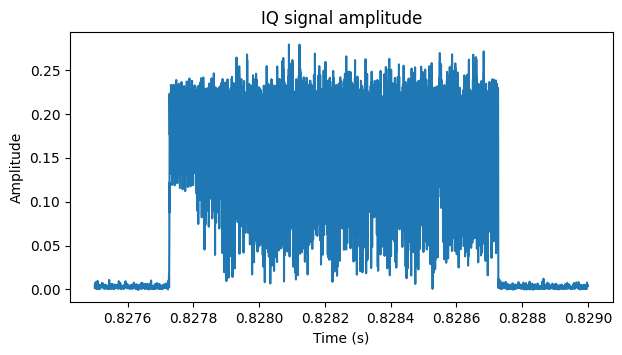

In [94]:
sel = slice(3310000, 3316000)
plt.plot(np.arange(x.size)[sel] / fs, np.abs(x[sel]))
plt.title('IQ signal amplitude')
plt.ylabel('Amplitude')
plt.xlabel('Time (s)');


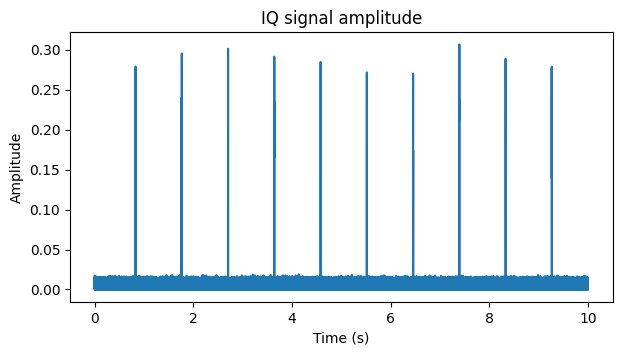

In [95]:
#plotting full recording
plt.plot(np.arange(x.size) / fs, np.abs(x))
plt.title('IQ signal amplitude')
plt.ylabel('Amplitude')
plt.xlabel('Time (s)');

In [96]:
stf_corr_complex = np.convolve(x[Tu//4:] * np.conjugate(x[:-Tu//4]), np.ones(2 * Ts - Tu//4))

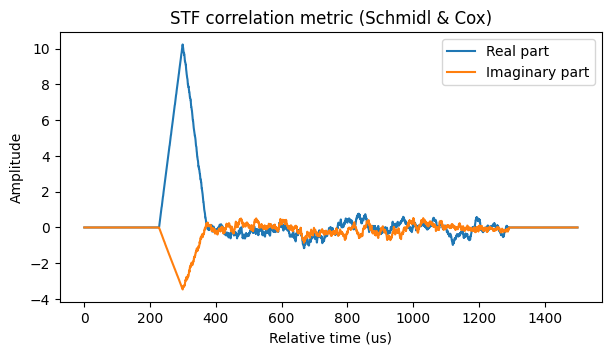

In [97]:
sel = slice(3310000, 3316000)
tax = np.arange(stf_corr_complex[sel].size) / fs * 1e6
plt.plot(tax, stf_corr_complex.real[sel], label='Real part')
plt.plot(tax, stf_corr_complex.imag[sel], label='Imaginary part')
plt.legend()
plt.title('STF correlation metric (Schmidl & Cox)')
plt.ylabel('Amplitude')
plt.xlabel('Relative time (us)');

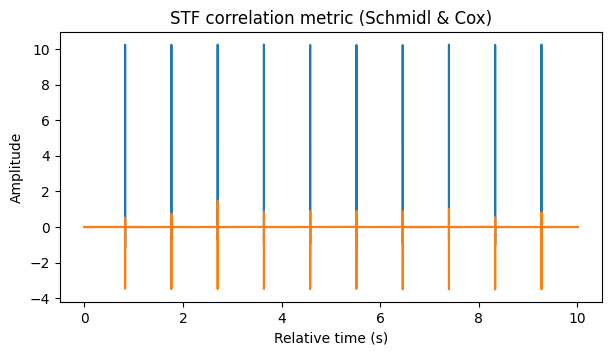

In [99]:
#plotting full recording
tax = np.arange(stf_corr_complex.size) / fs
plt.plot(tax, stf_corr_complex.real, label='Real part')
plt.plot(tax, stf_corr_complex.imag, label='Imaginary part')
plt.title('STF correlation metric (Schmidl & Cox)')
plt.ylabel('Amplitude')
plt.xlabel('Relative time (s)');

In [100]:
stf_corr = np.abs(stf_corr_complex)
del stf_corr_complex

In [101]:
detect_window = 6 * Ts
norm_window = (-Ts, -Ts//2)
local_maxima_window = (-2*Ts, 2*Ts)
stf_corr_w = stf_corr[:stf_corr.size//detect_window*detect_window].reshape(-1, detect_window)
max_value_norm = np.empty(stf_corr_w.shape[0])
max_idx = np.empty(stf_corr_w.shape[0], 'int')
for j in range(max_idx.size):
    a = np.argmax(stf_corr_w[j])
    max_idx[j] = a + j * detect_window - (2 * Ts - Tu//4 - 1)
    norm = np.average(np.abs(x[max_idx[j] + norm_window[0]:max_idx[j] + norm_window[1]])**2)
    max_value_norm[j] = stf_corr_w[j, a] / norm
    b = j * detect_window + a
    local_maxima = stf_corr_w[j, a] >= np.max(stf_corr[b + local_maxima_window[0]:b + local_maxima_window[1]])
    if not local_maxima:
        max_value_norm[j] = np.nan

threshold_dB = 30
detections = max_value_norm >= 10**(threshold_dB/10)
# Remove these detections manually, since they are false detections
# that cause a correct SIG CRC by chance and trigger some unsopported features
# assertions
#detections[np.where(detections)[0][1938]] = False
#detections[np.where(detections)[0][2243]] = False

/home/alakhdar/Projets/DynLib10.0/FutureSDR/.venv/lib64/python3.14/site-packages/numpy/lib/_function_base_impl.py:576: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/home/alakhdar/Projets/DynLib10.0/FutureSDR/.venv/lib64/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


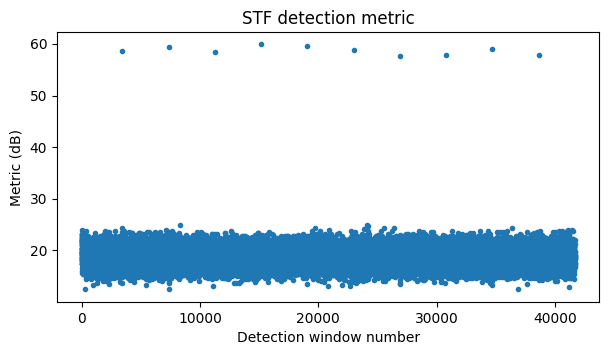

In [104]:
plt.plot(10*np.log10(max_value_norm), '.')
plt.title('STF detection metric')
plt.xlabel('Detection window number')
plt.ylabel('Metric (dB)');

PPDU 0 at sample 3310909
-----------------------------
Coarse CFO: -6494.387 Hz
Fine CFO: 40.400 Hz
Total CFO: -6453.987 Hz
Coarse STO: 0.00 samples
Fine STO: 0.351 samples
Total STO: 0.351 samples

SIG contents
STBC = 0
uplink indication = 1
BW = 0
Nsts = 0
SIG ID = 0x000
short GI = 0
coding = BCC
LDPC extra = 1
MCS = 0 (BPSK 1/2)
smoothing = 1
aggregation = 0
length = 60 (N_sym = 19)
response indication = 0
traveling pilots = 0
NDP indication = 0

noise sigma = 0.127
BER = 0.0

PPDU 1 at sample 7062981
-----------------------------
Coarse CFO: -6519.986 Hz
Fine CFO: 16.862 Hz
Total CFO: -6503.123 Hz
Coarse STO: 0.00 samples
Fine STO: 0.632 samples
Total STO: 0.632 samples

SIG contents
STBC = 0
uplink indication = 1
BW = 0
Nsts = 0
SIG ID = 0x000
short GI = 0
coding = BCC
LDPC extra = 1
MCS = 0 (BPSK 1/2)
smoothing = 1
aggregation = 0
length = 60 (N_sym = 19)
response indication = 0
traveling pilots = 0
NDP indication = 0

noise sigma = 0.136
BER = 0.0

PPDU 2 at sample 10814800
----

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


noise sigma = 0.119
BER = 0.0

PPDU 9 at sample 37074910
-----------------------------
Coarse CFO: -6535.110 Hz
Fine CFO: 16.368 Hz
Total CFO: -6518.742 Hz
Coarse STO: 0.00 samples
Fine STO: 0.636 samples
Total STO: 0.636 samples

SIG contents
STBC = 0
uplink indication = 1
BW = 0
Nsts = 0
SIG ID = 0x000
short GI = 0
coding = BCC
LDPC extra = 1
MCS = 0 (BPSK 1/2)
smoothing = 1
aggregation = 0
length = 60 (N_sym = 19)
response indication = 0
traveling pilots = 0
NDP indication = 0

noise sigma = 0.149
BER = 0.0



Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

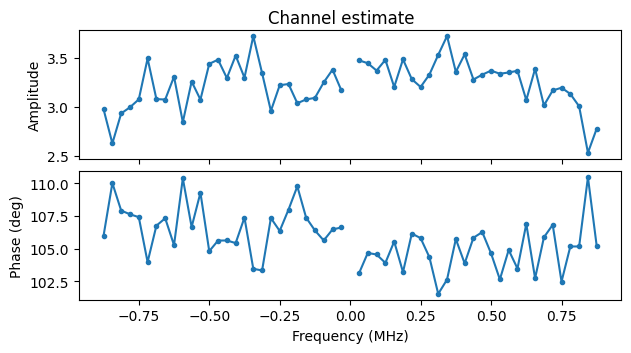

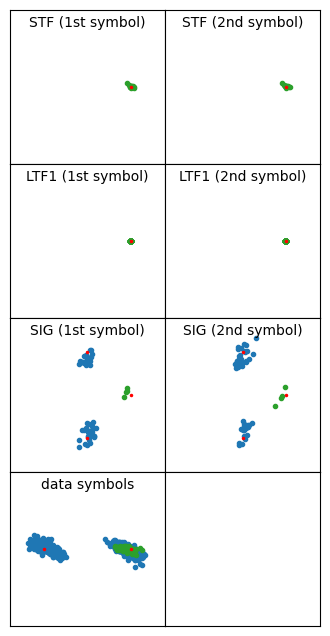

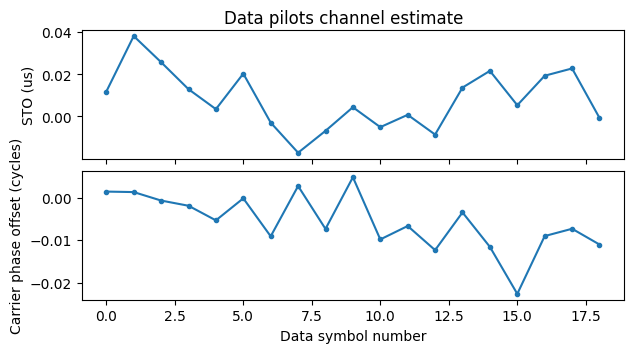

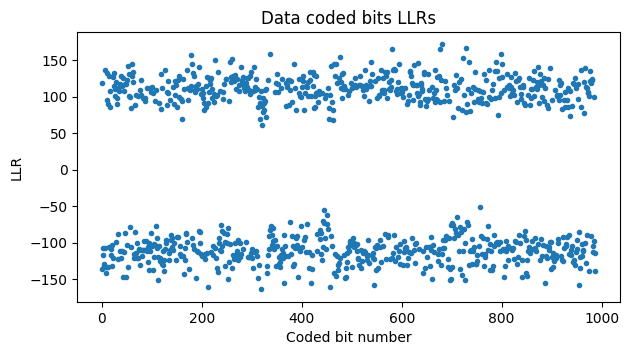

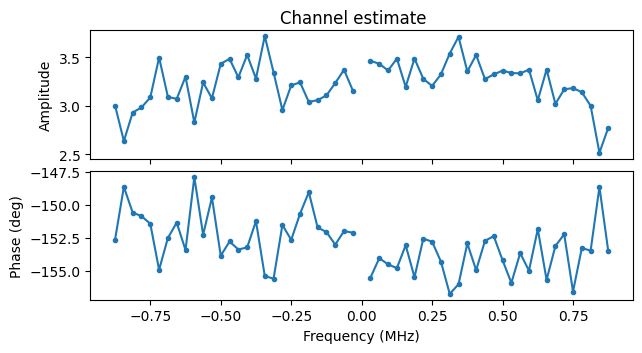

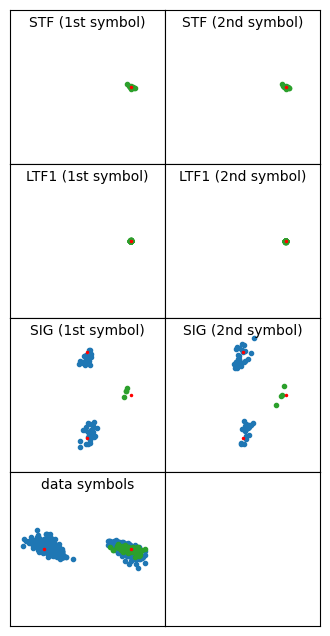

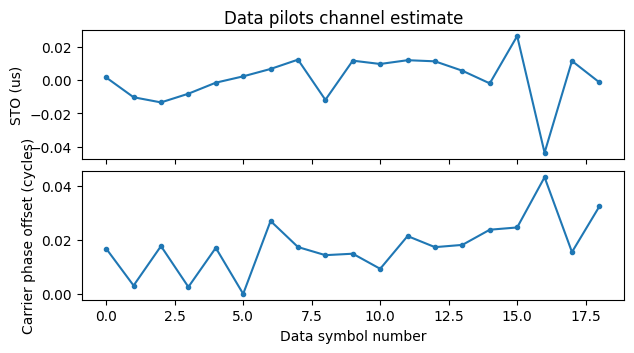

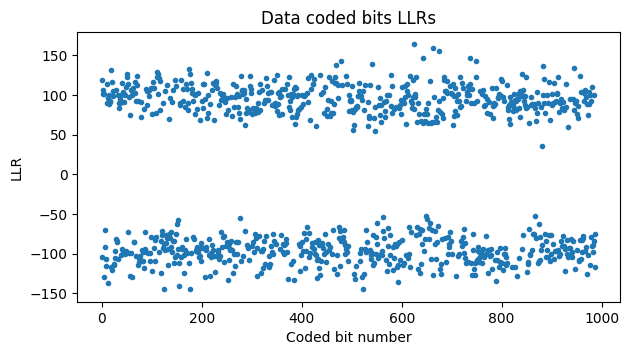

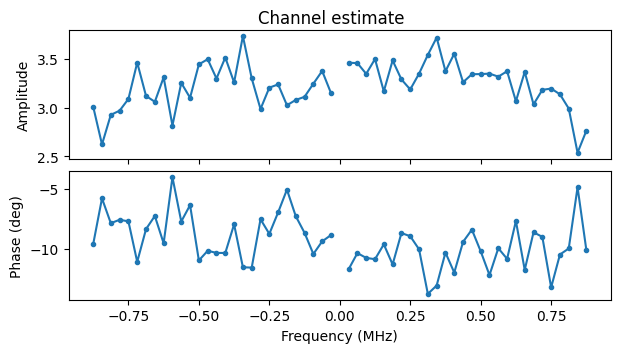

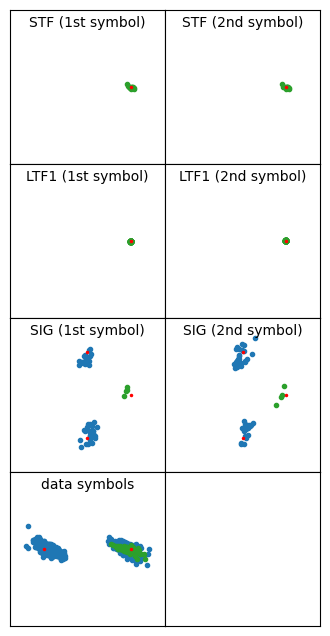

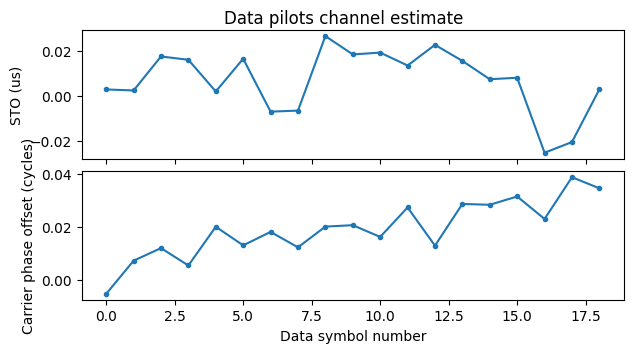

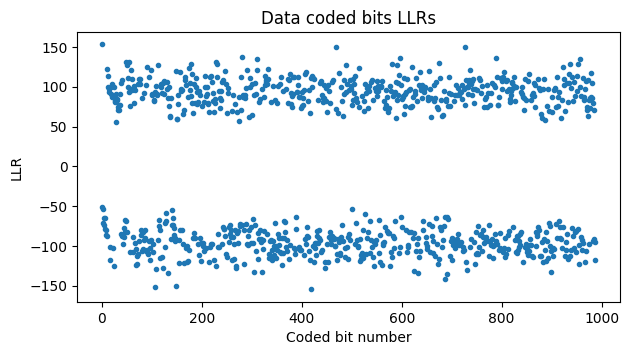

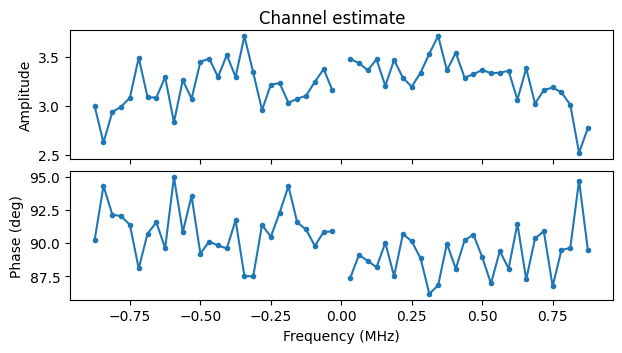

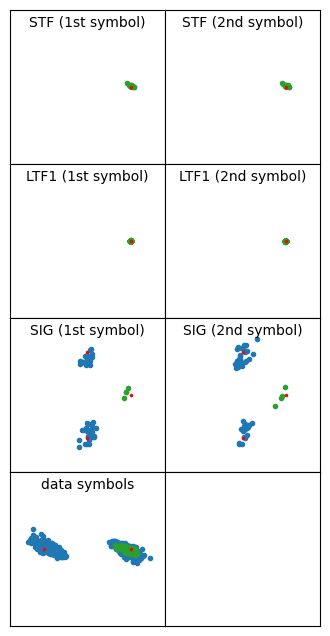

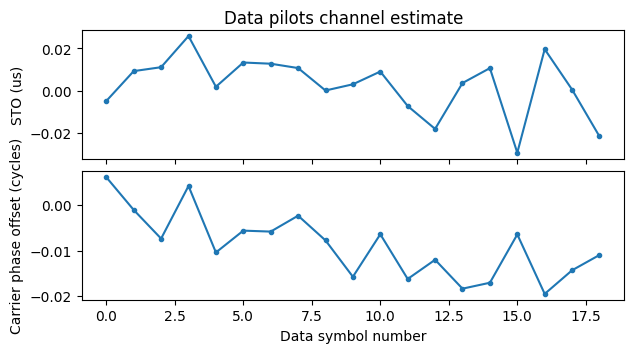

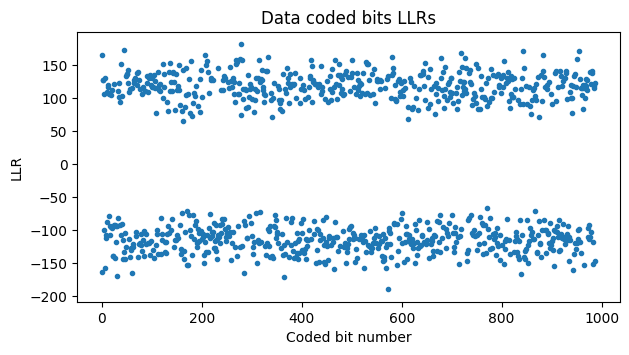

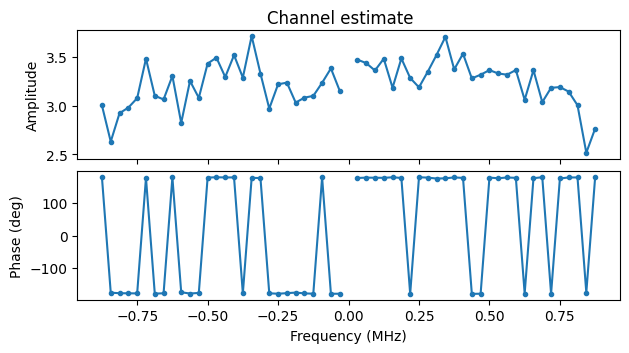

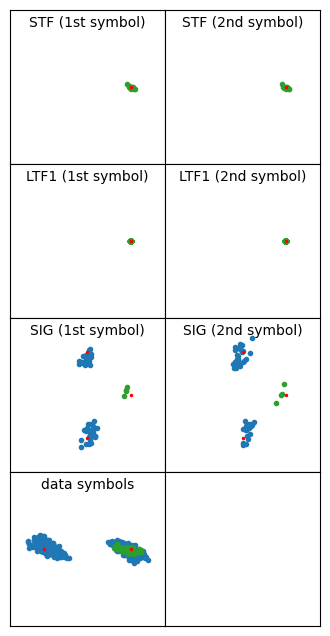

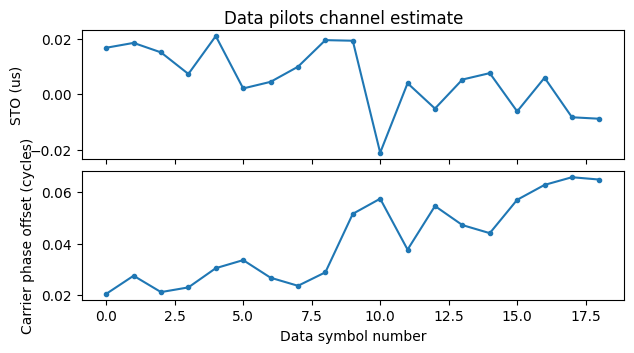

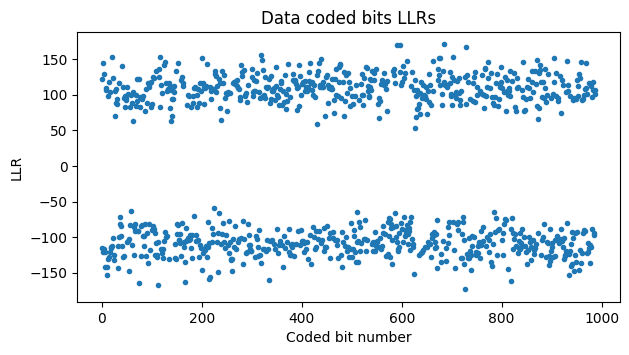

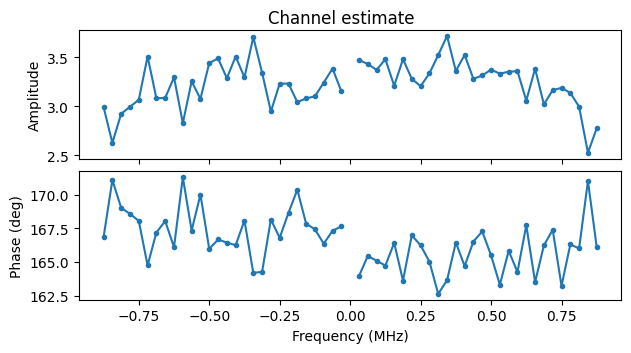

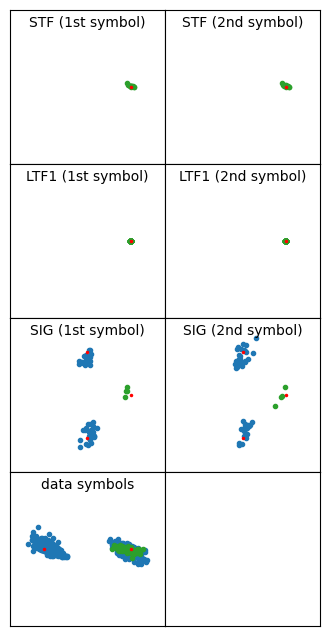

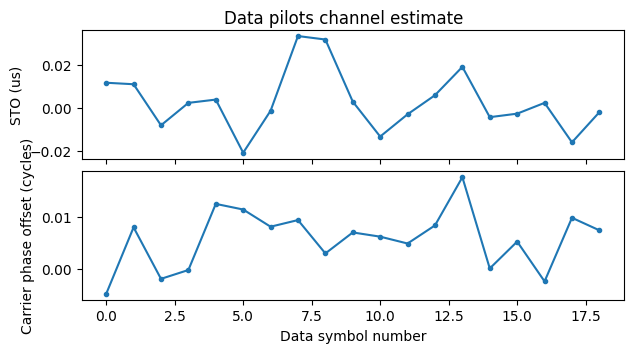

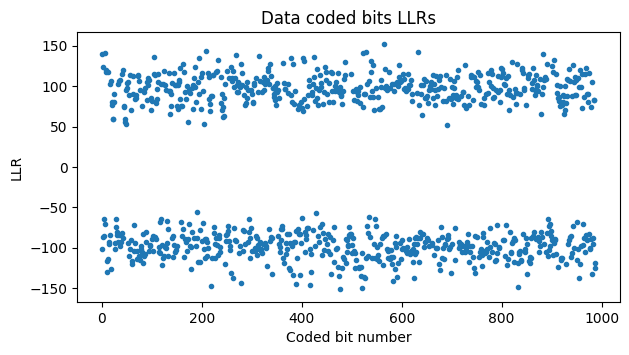

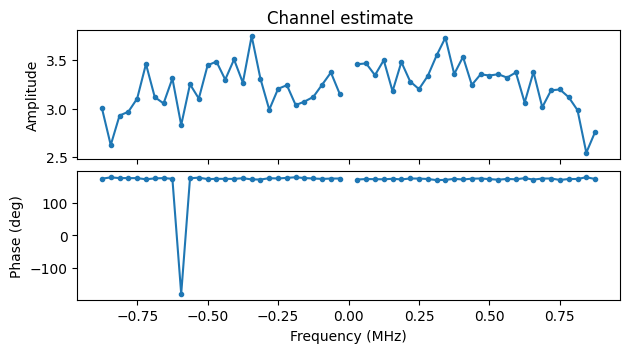

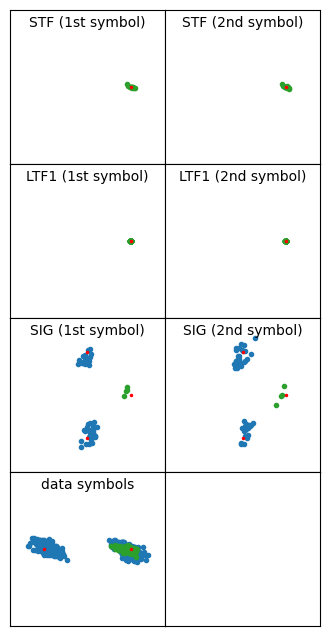

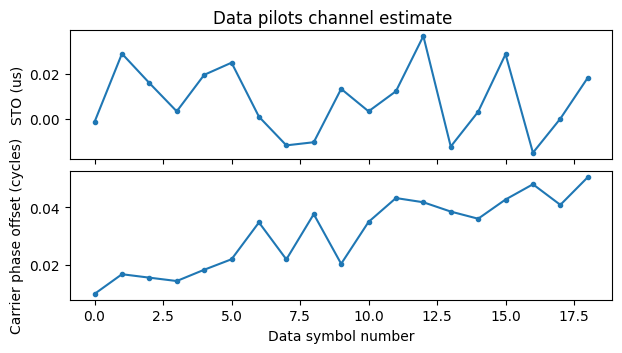

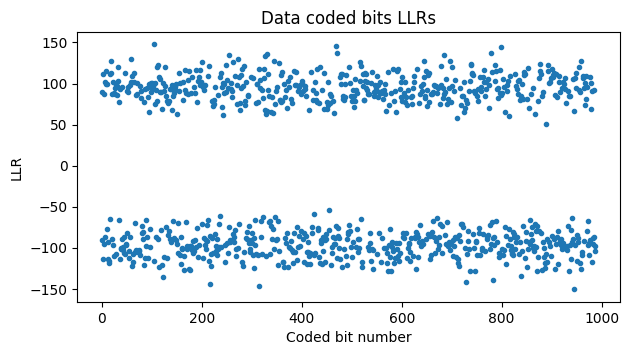

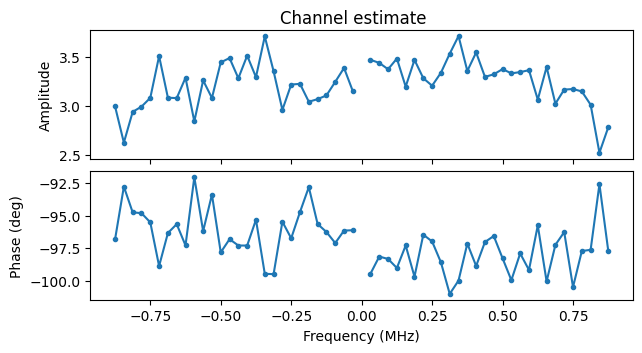

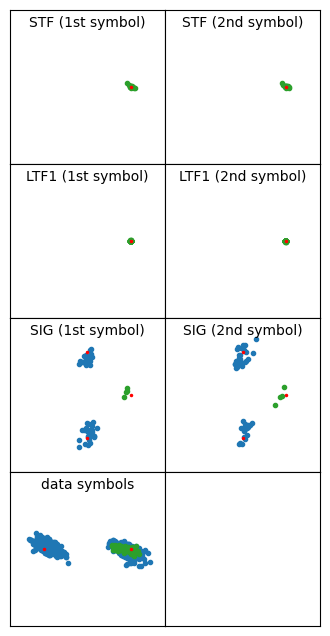

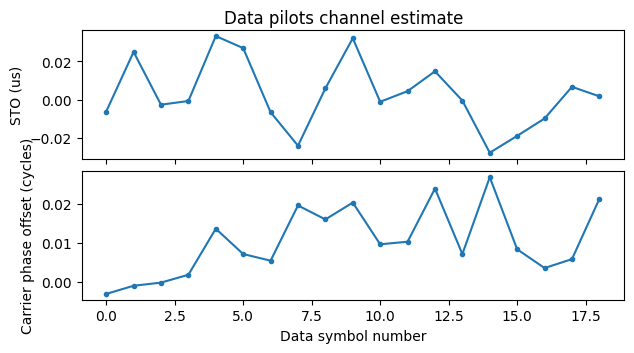

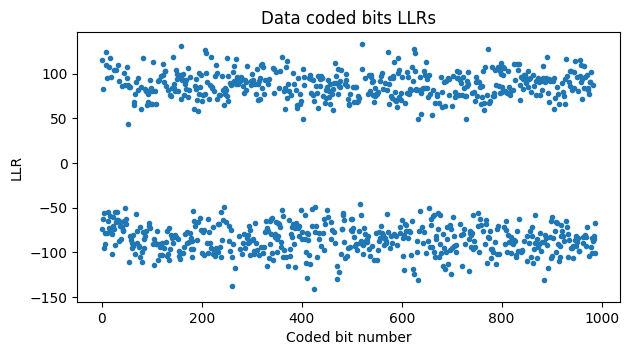

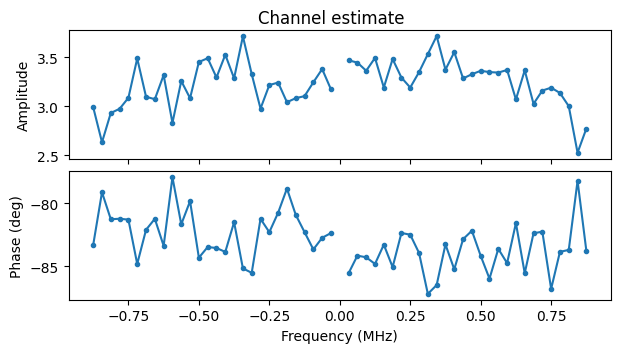

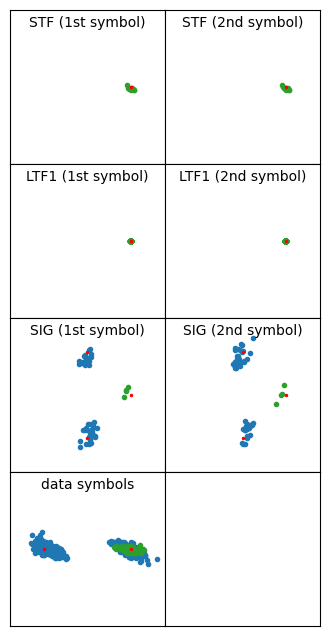

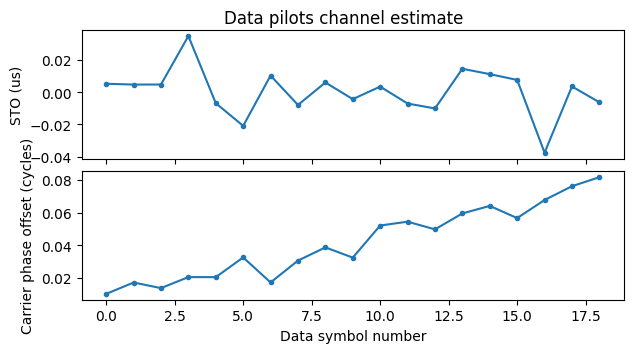

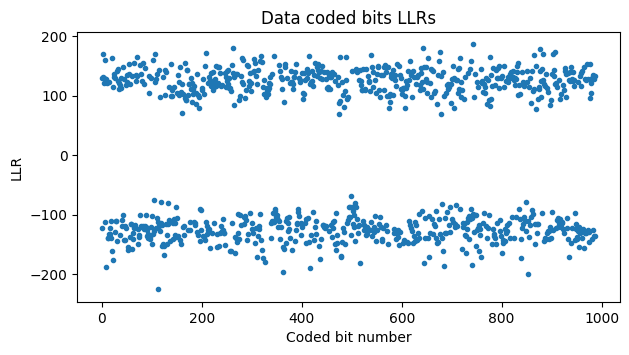

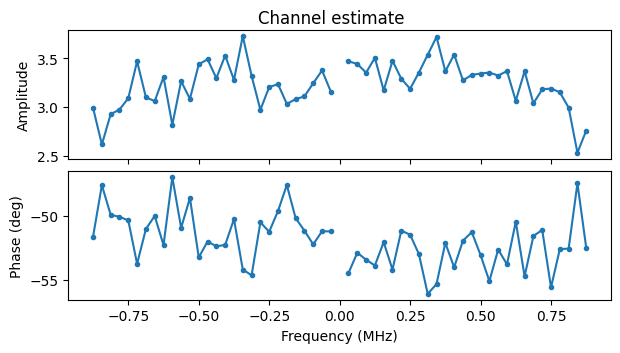

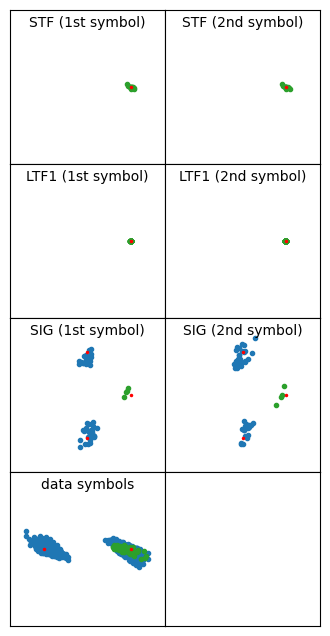

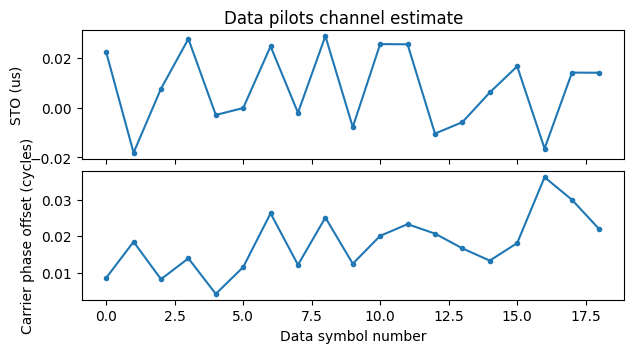

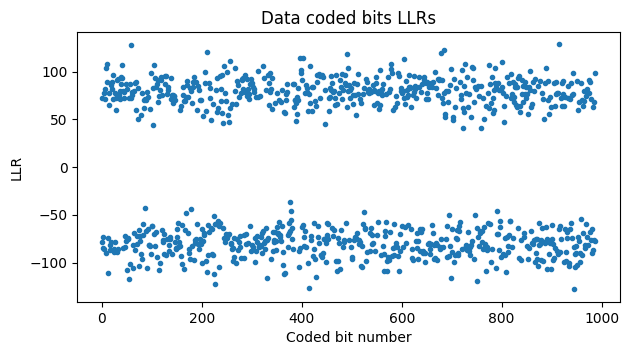

In [105]:
for n, start_idx in enumerate(max_idx[detections]):
    print(f'PPDU {n} at sample {start_idx}')
    print('-----------------------------')
    decode_ppdu(start_idx, plots=n < 16, verbose=True)
    print()

In [109]:
scapy.utils.wrpcap('802_11_ah.pcap', wireshark_packets)

In [106]:
# Long PPDU
decode_ppdu(8476092, plots=True, verbose=True);

Coarse CFO: -19122.309 Hz
Fine CFO: 5540.845 Hz
Total CFO: -13581.464 Hz
Coarse STO: 0.00 samples
Fine STO: 0.529 samples
Total STO: 0.529 samples


/tmp/ipykernel_319606/3422983186.py:127: UserWarning: failed to decoded SIG-A (start_idx = 8476093)
  warnings.warn(f'failed to decoded {sig_name} (start_idx = {start_idx})')


In [107]:
# Short GI PPDU (bad constellation; has some bit errors)
decode_ppdu(11087797, plots=True, verbose=True)

Coarse CFO: -4096.490 Hz
Fine CFO: 1947.218 Hz
Total CFO: -2149.272 Hz
Coarse STO: 12.31 samples
Fine STO: -0.396 samples
Total STO: 11.912 samples


/tmp/ipykernel_319606/3422983186.py:127: UserWarning: failed to decoded SIG (start_idx = 11087809)
  warnings.warn(f'failed to decoded {sig_name} (start_idx = {start_idx})')


In [108]:
# Retransmission (same SN, but retry flag not set) with lower MCS
# Still not great constellation, but can be decoded
decode_ppdu(11093664, plots=True, verbose=True)

Coarse CFO: 15910.600 Hz
Fine CFO: 4509.167 Hz
Total CFO: 20419.767 Hz
Coarse STO: -9.85 samples
Fine STO: -1.115 samples
Total STO: -10.961 samples


AssertionError: 

Coarse CFO: 11784.394 Hz
Fine CFO: 368.971 Hz
Total CFO: 12153.364 Hz
Coarse STO: 0.00 samples
Fine STO: 0.203 samples
Total STO: 0.203 samples

SIG contents
STBC = 0
uplink indication = 0
BW = 0
Nsts = 0
SIG ID = 0x001
short GI = 0
coding = BCC
LDPC extra = 1
MCS = 1 (QPSK 1/2)
smoothing = 0
aggregation = 0
length = 40 (N_sym = 7)
response indication = 0
traveling pilots = 0
NDP indication = 0

noise sigma = 0.213
BER = 0.009615384615384616


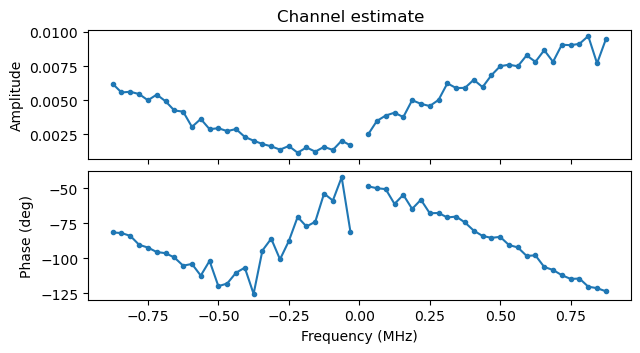

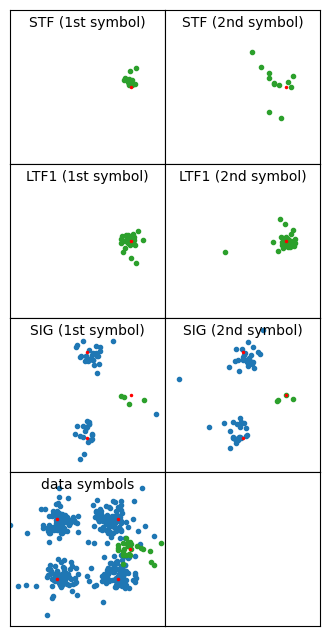

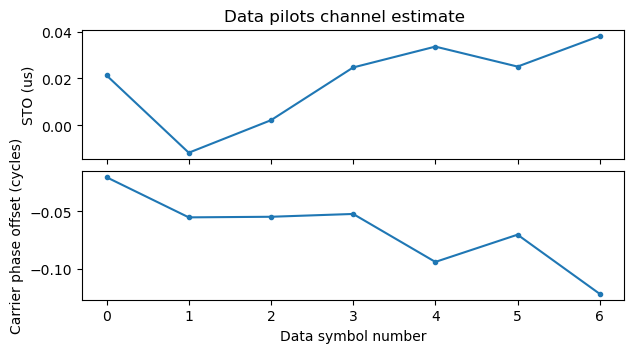

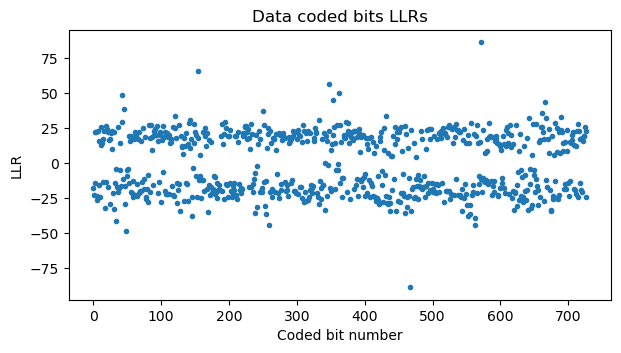

In [ ]:
# fading in the monitor screen signal
decode_ppdu(131510715, plots=True, verbose=True);

# Rust pipeline diagnostic dumps

These cells load and plot the binary files written by `rx_debug` into `plots/`. Run `cargo run --release --bin rx_debug` first.


In [ ]:
import os
PLOTS = 'plots'
def _exists(name): return os.path.exists(os.path.join(PLOTS, name))
for f in ['stf_corr.cf32','stf_metric.f32','sync_short_out.cf32',
          'sync_long_corr_mag.f32','ltf_td.cf32','stf_td.cf32',
          'h_est.cf32','sig1.cf32','sig2.cf32','ltf1_eq.cf32','data_syms.cf32']:
    print(f'{f:30s} {"present" if _exists(f) else "MISSING"}')


## STF detection metric (rust-pipeline streaming)


In [ ]:
# Same algorithm as the offline `max_value_norm` cell above, but on the
# rust streaming dump. Should produce identical peak heights & positions.
m_rust = np.fromfile(os.path.join(PLOTS, 'stf_metric.f32'), 'float32')
DETECT_WIN = 6 * Ts
LOCAL_MAX_R = 2 * Ts
POWER_WIN = Ts // 2
DB_OFFSET = 10 * np.log10(POWER_WIN)  # ~19.03 dB (sum→mean)
n_blocks = m_rust.size // DETECT_WIN
blocks = m_rust[:n_blocks*DETECT_WIN].reshape(n_blocks, DETECT_WIN)
argmaxs = np.argmax(blocks, axis=1)
block_max = blocks[np.arange(n_blocks), argmaxs]
abs_idx = argmaxs + np.arange(n_blocks) * DETECT_WIN
is_lm = np.array([
    block_max[j] >= np.max(m_rust[max(0,abs_idx[j]-LOCAL_MAX_R):min(m_rust.size,abs_idx[j]+LOCAL_MAX_R)])
    for j in range(n_blocks)])
with np.errstate(divide='ignore'):
    db = 10*np.log10(block_max) + DB_OFFSET
db_masked = np.where(is_lm, db, np.nan)
plt.figure(figsize=(11, 3.5))
plt.plot(db_masked, '.', markersize=3)
plt.axhline(30, color='grey', ls='--', lw=1, label='30 dB threshold')
plt.title('Rust pipeline — STF detection metric')
plt.xlabel('Detection window number')
plt.ylabel('Metric (dB, notebook-equivalent)')
plt.legend(); plt.grid(alpha=0.3)
print(f'{n_blocks} blocks, {int(np.nansum(db_masked >= 30))} above 30 dB')


## SyncLong correlation peaks (first PPDU)


In [ ]:
if _exists('sync_long_corr_mag.f32'):
    cm = np.fromfile(os.path.join(PLOTS, 'sync_long_corr_mag.f32'), 'float32')
    order = np.argsort(cm)[::-1]
    p1, p2 = sorted(order[:2])
    plt.figure(figsize=(11, 3.5))
    plt.plot(cm, lw=0.6)
    plt.axvline(p1, color='C1', alpha=0.5, lw=0.8, label=f'peak1 @ {p1}')
    plt.axvline(p2, color='C2', alpha=0.5, lw=0.8, label=f'peak2 @ {p2} (gap={p2-p1}, expected {Tu})')
    plt.title('SyncLong cross-correlation magnitude (first PPDU)')
    plt.xlabel('Sample within 2·Ts search window')
    plt.ylabel('|corr|')
    plt.legend()
    print(f'top-2 peaks: {p1}, {p2} (gap={p2-p1})')
else:
    print('no sync_long_corr_mag.f32 — SyncLong never ran (no SyncShort lock)')


## LTF time-domain (what SyncLong selected, pre-equalisation)


In [ ]:
if _exists('ltf_td.cf32'):
    z = np.fromfile(os.path.join(PLOTS, 'ltf_td.cf32'), 'complex64')
    fig, axs = plt.subplots(3, 1, figsize=(11, 7))
    axs[0].plot(np.abs(z), lw=0.7)
    axs[0].axvline(Tu, color='grey', ls='--', lw=0.6)
    axs[0].set_title('LTF time-domain |x|'); axs[0].set_ylabel('|x|')
    if z.size >= 2*Tu:
        s1 = np.fft.fftshift(np.fft.fft(z[:Tu]))
        s2 = np.fft.fftshift(np.fft.fft(z[Tu:2*Tu]))
        f = np.arange(-Tu//2, Tu//2)
        axs[1].plot(f, np.abs(s1), '.-'); axs[1].set_ylabel('|FFT(sym1)|')
        axs[2].plot(f, np.abs(s2), '.-'); axs[2].set_ylabel('|FFT(sym2)|')
        axs[2].set_xlabel('Subcarrier offset from DC')
        for ax in axs[1:]: ax.axvspan(-28, 28, color='grey', alpha=0.1)
    fig.tight_layout()
else:
    print('no ltf_td.cf32')


## SyncShort output stream (CFO-corrected, what SyncLong sees)

If SyncShort latches at the right moment, this stream should show the expected envelope: a flat plateau (rest of STF) → small dip (LTF1 GI) → flat plateau (LTF1 sym1+sym2) → SIG → data.


In [ ]:
if _exists('sync_short_out.cf32'):
    z = np.fromfile(os.path.join(PLOTS, 'sync_short_out.cf32'), 'complex64')
    n_show = min(z.size, 5000)
    fig, axs = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
    axs[0].plot(np.abs(z[:n_show]), lw=0.7); axs[0].set_ylabel('|x|')
    axs[0].set_title(f'SyncShort output |x|  (first {n_show} samples of {z.size})')
    axs[1].plot(z[:n_show].real, lw=0.5, label='re'); axs[1].plot(z[:n_show].imag, lw=0.5, label='im')
    axs[1].set_ylabel('IQ'); axs[1].set_xlabel('Sample'); axs[1].legend()
    fig.tight_layout()
else:
    print('no sync_short_out.cf32 — SyncShort never entered Copy state')


## First-PPDU channel estimate (h_est) and equalised constellations


In [ ]:
active_off = np.array([k for k in range(-28, 29) if k != 0])
if _exists('h_est.cf32'):
    h = np.fromfile(os.path.join(PLOTS, 'h_est.cf32'), 'complex64')
    f_mhz = active_off * (fs / Tu) * 1e-6
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(10, 4))
    axs[0].plot(f_mhz[:h.size], np.abs(h), '.-'); axs[0].set_ylabel('Amplitude')
    axs[1].plot(f_mhz[:h.size], np.rad2deg(np.angle(h)), '.-')
    axs[1].set_ylabel('Phase (deg)'); axs[1].set_xlabel('Frequency (MHz)')
    fig.suptitle('First PPDU — channel estimate (rust pipeline)')
    fig.tight_layout()
else:
    print('no h_est.cf32 — no PPDU was decoded')


In [ ]:
# 7-panel constellation grid: STF1, STF2, LTF1-1, LTF1-2, SIG1, SIG2, data
if all(_exists(f) for f in ['sig1.cf32','sig2.cf32','data_syms.cf32']):
    sig1 = np.fromfile(os.path.join(PLOTS, 'sig1.cf32'), 'complex64')
    sig2 = np.fromfile(os.path.join(PLOTS, 'sig2.cf32'), 'complex64')
    data = np.fromfile(os.path.join(PLOTS, 'data_syms.cf32'), 'complex64')
    ltf_eq = np.fromfile(os.path.join(PLOTS, 'ltf1_eq.cf32'), 'complex64') if _exists('ltf1_eq.cf32') else None
    stf_td = np.fromfile(os.path.join(PLOTS, 'stf_td.cf32'), 'complex64') if _exists('stf_td.cf32') else np.array([],'c8')
    h = np.fromfile(os.path.join(PLOTS, 'h_est.cf32'), 'complex64') if _exists('h_est.cf32') else None

    # Demodulate STF (notebook recipe) for whatever samples are available.
    stf_eq_list = []
    if h is not None and stf_td.size:
        cp_offset, cp_corr = Tcp//2, -Tcp//2
        # build h at offsets -26..+26 (53-element array, 0 at DC) from h_est at -28..+28
        h_53 = np.concatenate([h[2:28], [0+0j], h[28:54]])
        nz = stf_syms != 0
        for j in range(2):
            start = j*Ts + cp_offset
            if start + Tu > stf_td.size: break
            spec = (np.fft.fftshift(np.fft.fft(stf_td[start:start+Tu]))
                    * np.exp(1j*2*np.pi*cp_corr*np.fft.fftshift(np.fft.fftfreq(Tu))))
            sub = spec[-26+Tu//2 : 27+Tu//2] * np.conjugate(stf_syms)
            with np.errstate(divide='ignore', invalid='ignore'):
                eq = sub[nz] / h_53[nz]
            stf_eq_list.append(eq * np.sqrt(12/56))

    fig, axs = plt.subplots(4, 2, figsize=(7, 11))
    titles = [
        ('STF (1st symbol)', stf_eq_list[0] if len(stf_eq_list)>=1 else None, 'pilot'),
        ('STF (2nd symbol)', stf_eq_list[1] if len(stf_eq_list)>=2 else None, 'pilot'),
        ('LTF1 (1st symbol)', ltf_eq[:56] if ltf_eq is not None and ltf_eq.size==112 else None, 'pilot'),
        ('LTF1 (2nd symbol)', ltf_eq[56:] if ltf_eq is not None and ltf_eq.size==112 else None, 'pilot'),
        ('SIG (1st symbol)', sig1, 'BPSK_rot'),
        ('SIG (2nd symbol)', sig2, 'BPSK_rot'),
        ('data symbols', data, None),
    ]
    for k, (title, z, ref) in enumerate(titles):
        ax = axs[k//2, k%2]
        if z is None:
            ax.axis('off'); ax.text(0.5, 0.5, f'{title}\n(unavailable)', ha='center', va='center')
            continue
        constellation_plot(z, title=title, ref=ref or 'pilot', ax=ax,
                            color='C2' if ref=='pilot' else 'C0')
    axs[3,1].axis('off')
    fig.suptitle('First PPDU — equalised constellations (rust pipeline)', y=0.995)
    fig.tight_layout()
else:
    print('no SIG/data dumps — no PPDU was decoded')


## Notebook-side SyncLong cross-correlation (first PPDU)

Same algorithm as `SyncLong` in the rust pipeline, computed here on `x` starting at the first detected `start_idx`. Compare against `plots/sync_long_corr_mag.f32` (rust output).


In [ ]:
# Build LTF time-domain reference (matches rust `long_time_domain()`):
#   IFFT of `ltf` placed at the active subcarrier FFT bins.
ltf_spec_shifted = np.zeros(Tu, dtype=complex)
ltf_spec_shifted[subc] = ltf            # subc is in absolute fftshifted bin indices
ltf_td_ref = np.fft.ifft(np.fft.ifftshift(ltf_spec_shifted))   # complex, length Tu

first_idx = int(max_idx[detections][0])  # sample index of first detected STF
W = 2 * Ts                               # same search window as rust SEARCH_WINDOW
chunk = x[first_idx : first_idx + W + Tu]

# Two flavours of correlation:
#   matched filter (with conj):   sum x[i+k] · conj(ref[k])  — strict matched filter
#   plain inner product:          sum x[i+k] ·       ref[k]   — what rust does
corr_matched = np.array([np.sum(chunk[i:i+Tu] * np.conj(ltf_td_ref)) for i in range(W)])
corr_rust    = np.array([np.sum(chunk[i:i+Tu] *           ltf_td_ref) for i in range(W)])

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(11, 6))
for ax, c, name in [(axs[0], corr_matched, 'matched filter (Σ x·conj(ref))'),
                    (axs[1], corr_rust,    'rust-style (Σ x·ref, no conj)')]:
    mag = np.abs(c)
    order = np.argsort(mag)[::-1]
    p1, p2 = sorted(order[:2])
    ax.plot(mag, lw=0.6)
    ax.axvline(p1, color='C1', alpha=0.5, lw=0.8, label=f'peak1 @ {p1}')
    ax.axvline(p2, color='C2', alpha=0.5, lw=0.8,
               label=f'peak2 @ {p2}  gap={p2-p1}  (expected {Tu})')
    ax.set_title(f'SyncLong cc (notebook): {name}')
    ax.set_ylabel('|corr|')
    ax.legend(loc='upper right')
axs[1].set_xlabel(f'Sample offset from start_idx (search window {W})')
fig.tight_layout()


## Notebook-side LTF time-domain (first PPDU)

Slices `x` at the *known* preamble offsets: LTF1 sym1 starts at `start_idx + 2·Ts + 2·Tcp`, sym2 follows after `Tu`. Compare against `plots/ltf_td.cf32` (rust output: whatever SyncLong's correlator picked).


In [ ]:
first_idx = int(max_idx[detections][0])
ltf_offset = 2*Ts + 2*Tcp
ltf_td_nb = x[first_idx + ltf_offset : first_idx + ltf_offset + 2*Tu]

fig, axs = plt.subplots(3, 1, figsize=(11, 7))
axs[0].plot(np.abs(ltf_td_nb), lw=0.7)
axs[0].axvline(Tu, color='grey', ls='--', lw=0.6, label=f'sym1 / sym2 boundary (Tu = {Tu})')
axs[0].set_title(f'LTF time-domain (notebook), first PPDU @ x[{first_idx}], '
                 f'LTF1 starts at +{ltf_offset}')
axs[0].set_ylabel('|x|'); axs[0].legend(loc='upper right')

s1 = np.fft.fftshift(np.fft.fft(ltf_td_nb[:Tu]))
s2 = np.fft.fftshift(np.fft.fft(ltf_td_nb[Tu:2*Tu]))
f = np.arange(-Tu//2, Tu//2)
axs[1].plot(f, np.abs(s1), '.-'); axs[1].set_ylabel('|FFT(sym1)|')
axs[2].plot(f, np.abs(s2), '.-'); axs[2].set_ylabel('|FFT(sym2)|')
axs[2].set_xlabel('Subcarrier offset from DC')
for ax in axs[1:]:
    ax.axvspan(-28, 28, color='grey', alpha=0.1, label='active subcarriers')
    ax.legend(loc='upper right')
fig.tight_layout()
